# Using a pre-arranged simulation workflow
* Pre-arranged workflows are available which apply the steps above (and maybe more) automatically
* These workflow functions can automatically simulate turbines of different design in a single function call
* These workflows can also be instructed to distribute themselves across multiple CPUs

Workflow:
1. Import required packages
2. Import csv with turbine placements
3. Simulate turbines
4. Plot different turbines

In [1]:
import reskit as rk
import pandas as pd

In [2]:
# Placement locations do not have to be put in as a pandas dataframe (a list of coordinates would also be okay), but
#  it is also the most flexible. Therefore, this manner is suggested

placements = pd.read_csv(rk.TEST_DATA["turbine_placements.csv"])

placements.head()

,capacity,hub_height,rotor_diam,lon,lat
0,4000,120,150,5.985195,50.797254
1,4000,120,130,5.994685,50.794208
2,4000,120,150,5.994107,50.800939
3,4000,120,130,6.004750,50.784432
4,4000,120,150,6.004174,50.791162


In [3]:
gen = rk.wind.onshore_wind_merra_ryberg2019_europe(
    placements=placements,
    merra_path=rk.TEST_DATA["merra-like"],  # path to MERRA2 data on your hard drive
    clc2012_path=rk.TEST_DATA[
        "clc-aachen_clipped.tif"
    ],  # Path to corine land cover (or anther land cover dataset) on your hard drive
    gwa_50m_path=rk.TEST_DATA[
        "gwa50-like.tif"
    ],  # Path to global wind atlas (at 50m, to match MERRA) on your hard drive
)

2026-02-19 14:43:52.407707 Based on max_batch_size=560, the total of 560 placements were split into 1 sub batches. Proceeding with batch 1/1 (id=0) with 560 placements.
2026-02-19 14:43:52.416780 Required tolerance of 0.01 reached after 0 additional iteration(s). Maximum remaining rel. deviation: 0.0.


/fast/home/t-miosga/code/reskit/reskit/wind/workflows/wind_workflow_manager.py:764: RuntimeWarning: divide by zero encountered in divide
  min_convergence = 1 - (tolerance / abs(_deviations_last - 1)) ** (1 / max_iterations)


In [4]:
gen

<xarray.Dataset> Size: 1MB
Dimensions:                         (location: 560, time: 71)
Coordinates:
  * location                        (location) int64 4kB 0 1 2 3 ... 557 558 559
  * time                            (time) datetime64[us] 568B 2015-01-01T00:...
Data variables:
    capacity                        (location) int64 4kB 4000 4000 ... 4000 4000
    hub_height                      (location) int64 4kB 120 120 120 ... 120 120
    rotor_diam                      (location) int64 4kB 150 130 150 ... 150 130
    lon                             (location) float64 4kB 5.985 5.995 ... 6.332
    lat                             (location) float64 4kB 50.8 50.79 ... 50.84
    powerCurve                      (location) object 4kB 'SPC:226,25' ... 'S...
    LRA_factor_elevated_wind_speed  (location) float64 4kB 0.7478 ... 0.7794
    roughness                       (location) float64 4kB 0.05 0.05 ... 0.05
    elevated_wind_speed             (time, location) float64 318kB 4.905 ... ...
    surface_pressure                (time, location) float64 318kB 1.012e+05 ...
    surface_air_temperature         (time, location) float64 318kB -1.014 ......
    capacity_factor                 (time, location) float64 318kB 0.07048 .....

In [5]:
# Access raw data
gen["capacity_factor"].data

array([[0.07047806, 0.05571119, 0.09921612, ..., 0.03727737, 0.08180391,
        0.0541426 ],
       [0.07390768, 0.05809232, 0.10299821, ..., 0.03592092, 0.0800284 ,
        0.05258938],
       [0.07133069, 0.05650117, 0.10015808, ..., 0.03326523, 0.07390768,
        0.0487753 ],
       ...,
       [0.0246053 , 0.01907235, 0.03727737, ..., 0.01803572, 0.04288669,
        0.02577928],
       [0.04074945, 0.03196664, 0.05969819, ..., 0.04004594, 0.08719858,
        0.05729489],
       [0.13549641, 0.1106725 , 0.1837451 , ..., 0.11358644, 0.21535322,
        0.15403718]])

In [6]:
# Recover as a dataframe
gen["capacity_factor"].to_dataframe().unstack(level=-1)

capacity_factor                                          \
location                        0         1         2         3         4     
time                                                                          
2015-01-01 00:30:00        0.070478  0.055711  0.099216  0.028192  0.077387   
2015-01-01 01:30:00        0.073908  0.058092  0.102998  0.028808  0.080028   
2015-01-01 02:30:00        0.071331  0.056501  0.100158  0.027581  0.077387   
2015-01-01 03:30:00        0.064602  0.050289  0.090850  0.024605  0.069629   
2015-01-01 04:30:00        0.080028  0.062953  0.109705  0.031325  0.085389   
...                             ...       ...       ...       ...       ...   
2015-01-03 18:30:00        0.019072  0.014601  0.028192  0.005930  0.021217   
2015-01-03 19:30:00        0.024605  0.019072  0.035921  0.009067  0.028808   
2015-01-03 20:30:00        0.024605  0.019072  0.037277  0.008689  0.028808   
2015-01-03 21:30:00        0.040749  0.031967  0.059698  0.015073  0.045797   
2015-01-03 22:30:00        0.135496  0.110672  0.183745  0.060507  0.147802   

                                                                       ...  \
location                  5         6         7         8         9    ...   
time                                                                   ...   
2015-01-01 00:30:00  0.060507  0.116519  0.063776  0.109705  0.062134  ...   
2015-01-01 01:30:00  0.062953  0.119470  0.066264  0.112613  0.064602  ...   
2015-01-01 02:30:00  0.060507  0.115540  0.063776  0.109705  0.062134  ...   
2015-01-01 03:30:00  0.054143  0.104903  0.057295  0.099216  0.055711  ...   
2015-01-01 04:30:00  0.067100  0.126424  0.070478  0.118485  0.067940  ...   
...                       ...       ...       ...       ...       ...  ...   
2015-01-03 18:30:00  0.015073  0.033922  0.015551  0.030056  0.014135  ...   
2015-01-03 19:30:00  0.020672  0.045797  0.021217  0.041457  0.019600  ...   
2015-01-03 20:30:00  0.021217  0.046536  0.022886  0.043608  0.021767  ...   
2015-01-03 21:30:00  0.035250  0.073046  0.037963  0.069629  0.037277  ...   
2015-01-03 22:30:00  0.119470  0.214252  0.127425  0.205469  0.125425  ...   

                                                                       \
location                  550       551       552       553       554   
time                                                                    
2015-01-01 00:30:00  0.105859  0.051052  0.102998  0.067940  0.078265   
2015-01-01 01:30:00  0.102998  0.049530  0.101102  0.066264  0.075641   
2015-01-01 02:30:00  0.095473  0.045797  0.093616  0.061319  0.070478   
2015-01-01 03:30:00  0.081804  0.037963  0.080028  0.051819  0.059698   
2015-01-01 04:30:00  0.092691  0.043608  0.090850  0.058893  0.067940   
...                       ...       ...       ...       ...       ...   
2015-01-03 18:30:00  0.006909  0.002093  0.005619  0.002714  0.003658   
2015-01-03 19:30:00  0.031967  0.011905  0.026975  0.014601  0.021217   
2015-01-03 20:30:00  0.055711  0.024027  0.051052  0.031325  0.040046   
2015-01-03 21:30:00  0.106817  0.051052  0.102998  0.067100  0.080915   
2015-01-03 22:30:00  0.257636  0.141621  0.252032  0.179446  0.204375   

                                                                       
location                  555       556       557       558       559  
time                                                                   
2015-01-01 00:30:00  0.074773  0.114562  0.037277  0.081804  0.054143  
2015-01-01 01:30:00  0.073046  0.111642  0.035921  0.080028  0.052589  
2015-01-01 02:30:00  0.067100  0.103950  0.033265  0.073908  0.048775  
2015-01-01 03:30:00  0.057295  0.089933  0.027581  0.062953  0.040749  
2015-01-01 04:30:00  0.064602  0.101102  0.031967  0.071331  0.046536  
...                       ...       ...       ...       ...       ...  
2015-01-03 18:30:00  0.003410  0.006249  0.001084  0.003658  0.001722  
2015-01-03 19:30:00  0.019072  0.029430  0.008689  0.021767  0.011905  
2015-

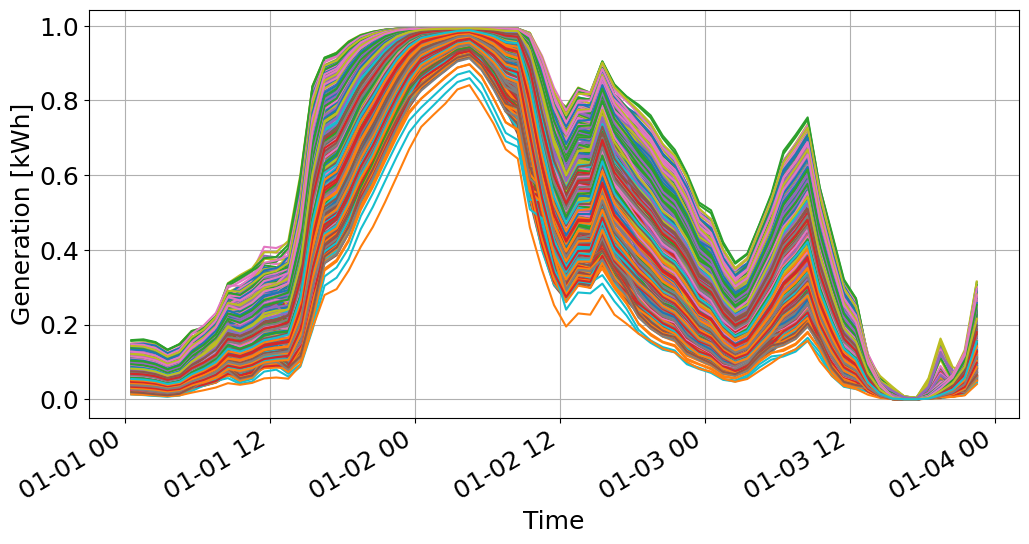

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.rc("font", size=18)
df = gen["capacity_factor"].to_dataframe().unstack(level=-1)
df.plot(legend=False, figsize=(12, 6))
plt.ylabel("Generation [kWh]")
plt.xlabel("Time")
plt.grid()
plt.show()